In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import SimpleITK as sitk


from predict_single_LVSA import  predict


## config
gpu_id=0
device = torch.device("cuda:{}".format(gpu_id) if (torch.cuda.is_available()) else "cpu")
if torch.cuda.is_available():
    torch.cuda.set_device(gpu_id)
os.environ["CUDA_VISIBLE_DEVICES"] = str(gpu_id)
model_path= '/home/engs2522/project/shared_projects/Cardiac_Multi_view_segmentation/checkpoints/LVSA/Unet_adv_chain.pth'
input_image_path = '/home/engs2522/project/shared_projects/Cardiac_Multi_view_segmentation/test_results/LVSA/001/LVSA_img_ED.nii.gz'


# standard prediction

In [2]:

torch.cuda.empty_cache()
model,im,pred = predict (model_path, input_image_path,save_pred_path=None, batch_size=1, crop_size=192,if_resample=True,if_z_score=True,gpu_id=gpu_id)     



<------Loading model-------->
init UNet_64


/home/engs2522/project/shared_projects/Cardiac_Multi_view_segmentation/model/init_weight.py:31: UserWarning: nn.init.kaiming_normal is now deprecated in favor of nn.init.kaiming_normal_.
  init.kaiming_normal(m.weight.data, a=0, mode='fan_in')
/home/engs2522/project/shared_projects/Cardiac_Multi_view_segmentation/model/init_weight.py:35: UserWarning: nn.init.normal is now deprecated in favor of nn.init.normal_.
  init.normal(m.weight.data, 1.0, 0.02)
/home/engs2522/project/shared_projects/Cardiac_Multi_view_segmentation/model/init_weight.py:36: UserWarning: nn.init.constant is now deprecated in favor of nn.init.constant_.
  init.constant(m.bias.data, 0.0)


load params from  /home/engs2522/project/shared_projects/Cardiac_Multi_view_segmentation/checkpoints/LVSA/Unet_adv_chain.pth
<------Loading data-------->
<------Preprocessing data-------->
<------Batchwise prediction-------->
<------Recover image information-------->


## Prediction with MC dropout

In [3]:
## MC dropout
torch.cuda.empty_cache()
mc_dropout_times= 10
decoder_dropout_rate=0.1
model,im,mc_pred = predict (model_path, input_image_path,save_pred_path=None, batch_size=1, crop_size=192,
if_resample=True,if_z_score=False,gpu_id=1,mc_dropout=mc_dropout_times,decoder_dropout_rate=decoder_dropout_rate)     


<------Loading model-------->
enable dropout
enable dropout
enable dropout
enable dropout
init UNet_64
load params from  /home/engs2522/project/shared_projects/Cardiac_Multi_view_segmentation/checkpoints/LVSA/Unet_adv_chain.pth
<------Loading data-------->
<------Preprocessing data-------->
<------Batchwise prediction-------->
<------Recover image information-------->


## Visualization

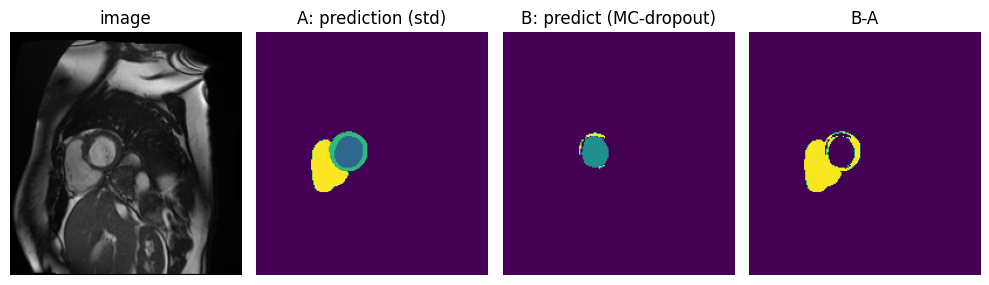

In [4]:
slice_id = 1
fig,axes = plt.subplots(1,4,figsize=(10,30))
axes[0].imshow(im[slice_id],cmap='gray')
axes[0].set_title('image')
axes[1].imshow(pred[slice_id])
axes[1].set_title('A: prediction (std)')
axes[2].imshow(mc_pred[slice_id])
axes[2].set_title('B: predict (MC-dropout)')
axes[3].imshow(mc_pred[slice_id]-pred[slice_id])
axes[3].set_title('B-A')
for ax in axes:
    ax.axis('off')
plt.tight_layout()

